In [43]:

from autoencoder import AutoEncoder, LSTMAutoEncoder
import json
from typing import List, Tuple
import numpy as np
import os
from dataset_utils import min_max_normalization, TimeSeriesAutoEncoderDataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from train_utils import Trainer
from eval_utils import Evaluator
import matplotlib.pyplot as plt


DATASET_PATH = "../dataset"
LTSF_ONLINE_RESULTS_PATH = "../ltsf/online_training/results"
LTSF_MODEL_NAME = "lstm"
LEN_WINDOW = 4

BATCH_SIZE = 1
TRAIN_EPOCH = 40
EARLY_STOP_GAIN = 0.01
EARLY_STOP_LOSS = 0.02

LR = 1e-1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [44]:

def clt_estimation(series: np.ndarray):
    return np.mean(series, axis=0), np.sqrt(np.std(series, axis=0))

In [45]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [46]:
def read_result(file_name: str) -> np.ndarray:
    dir = os.path.join(LTSF_ONLINE_RESULTS_PATH, LTSF_MODEL_NAME)
    result = None
    with open(os.path.join(dir, file_name), "r") as f:
        result = json.load(f)
    result = np.array(result)
    return result

In [47]:
def get_gt_and_pd(workload_name: str, name_split: str, is_scaled: bool) -> Tuple[np.ndarray, np.ndarray]:
    gt_file_name = None
    if is_scaled:
        gt_file_name = workload_name+"_gt_"+name_split+"_"+"scaled.json"
    else:
        gt_file_name = workload_name+"_gt_"+name_split+"_"+"original.json"

    pd_file_name = None
    if is_scaled:
        pd_file_name = workload_name+"_pd_"+name_split+"_"+"scaled.json"
    else:
        pd_file_name = workload_name+"_pd_"+name_split+"_"+"original.json"

    gt = read_result(gt_file_name)
    pd = read_result(pd_file_name)

    gt_0 = gt[:, :, 0, :]
    pd_0 = pd[:, :, 0, :]
    return gt_0, pd_0

In [48]:
def clt_test(data: np.ndarray, t_warmup: int):
    observations = []
    cp_idx = []
    for idx, x in enumerate(data):
        mu, sigma = None, None
        if len(observations) > t_warmup:
            mu, sigma = clt_estimation(observations)
        else:
            observations.append(x)
        if mu is not None and sigma is not None:
            if x < mu-3*sigma or x > mu+3*sigma:
                cp_idx.append(idx)
                observations.clear()
    return cp_idx

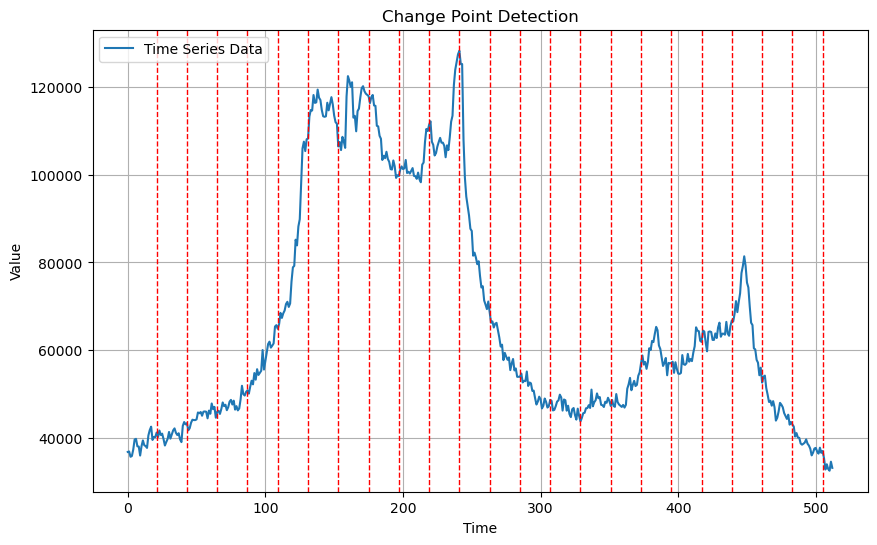

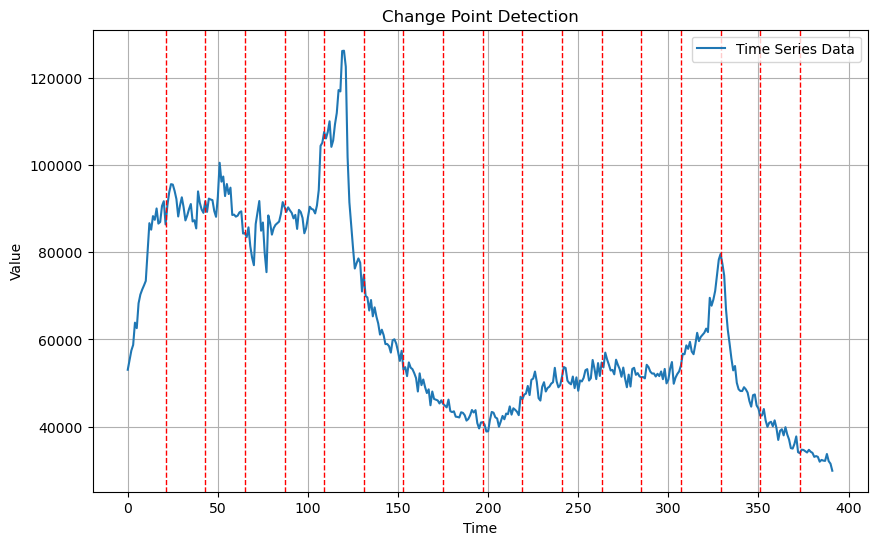

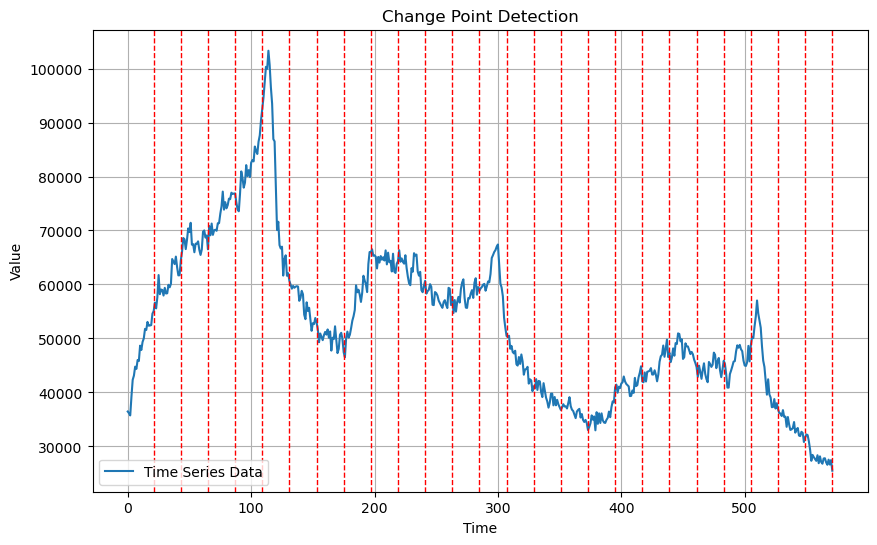

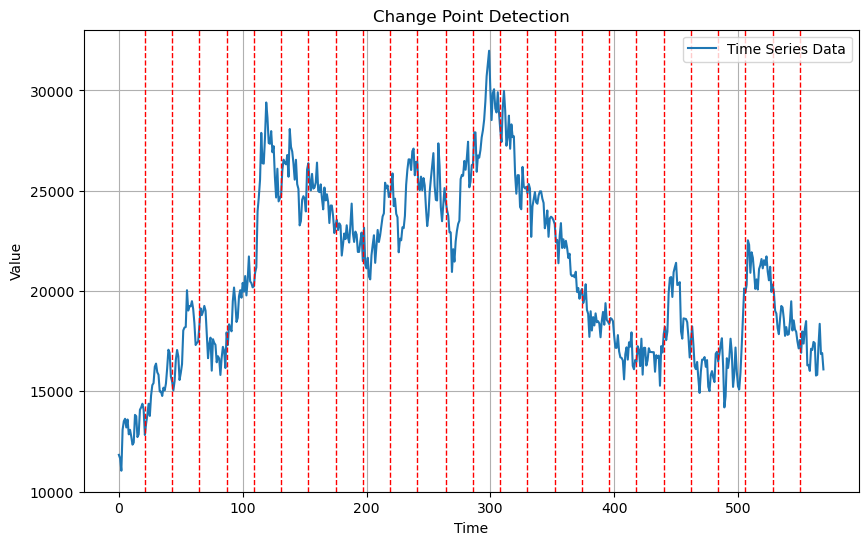

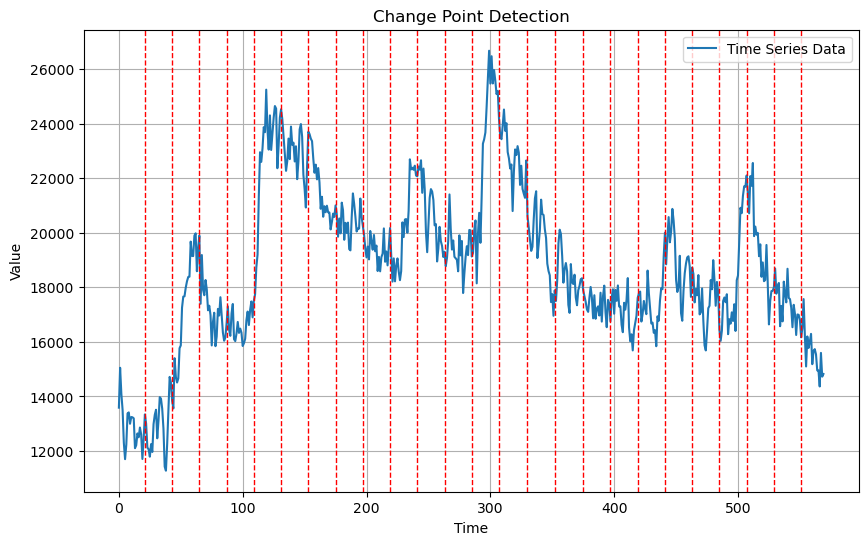

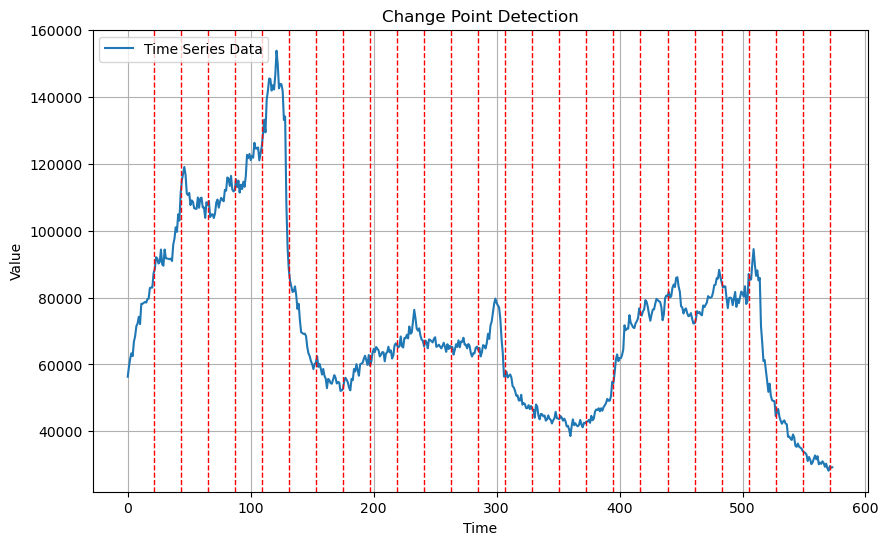

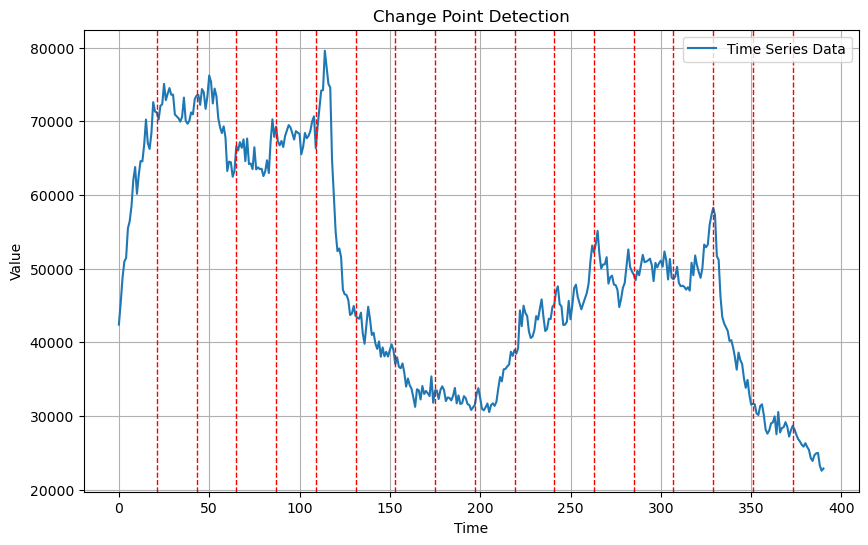

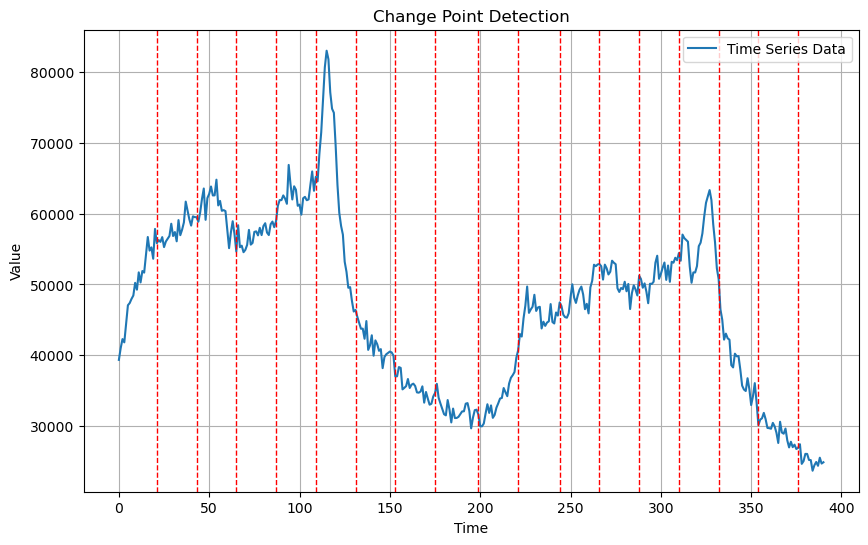

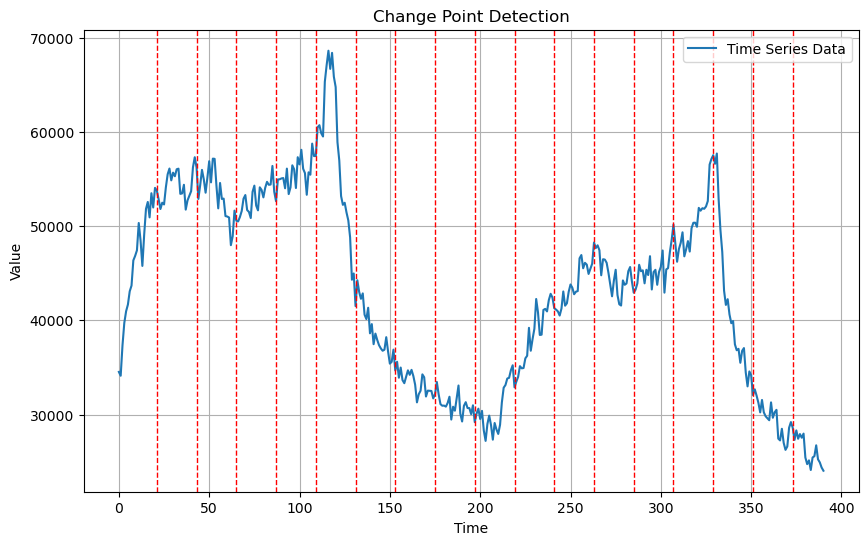

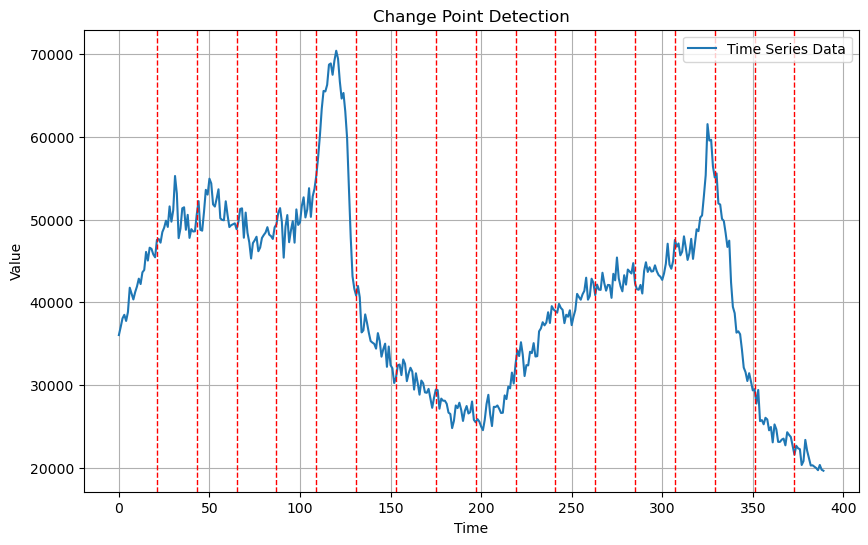

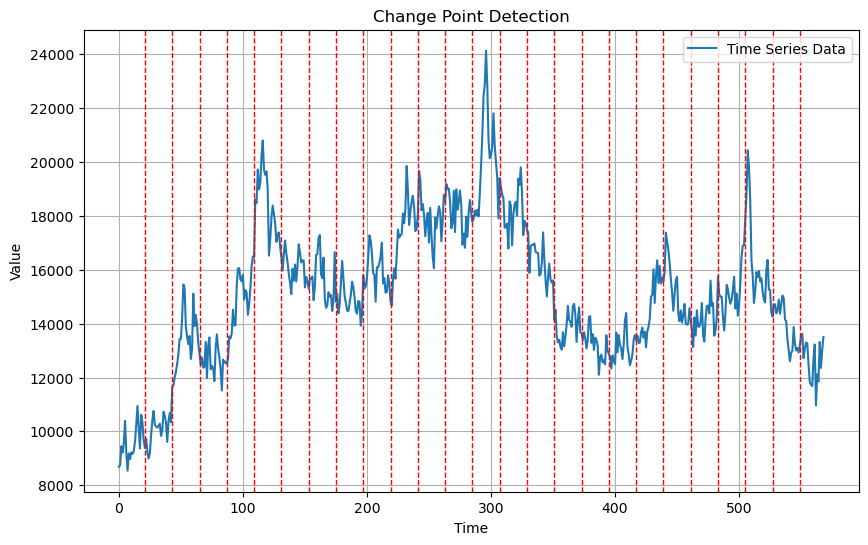

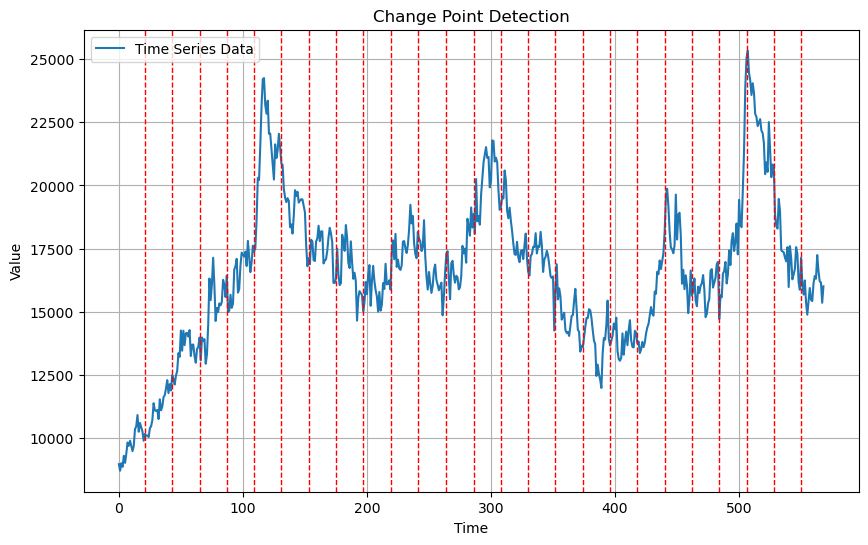

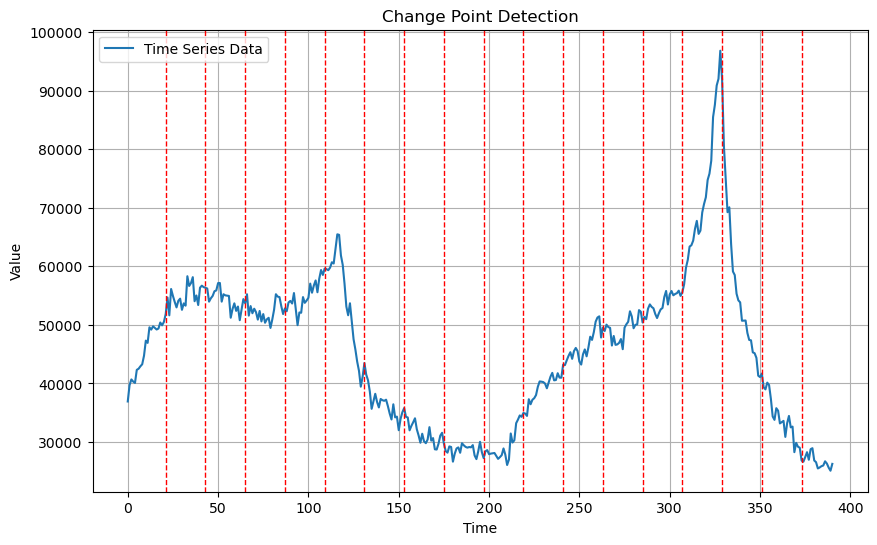

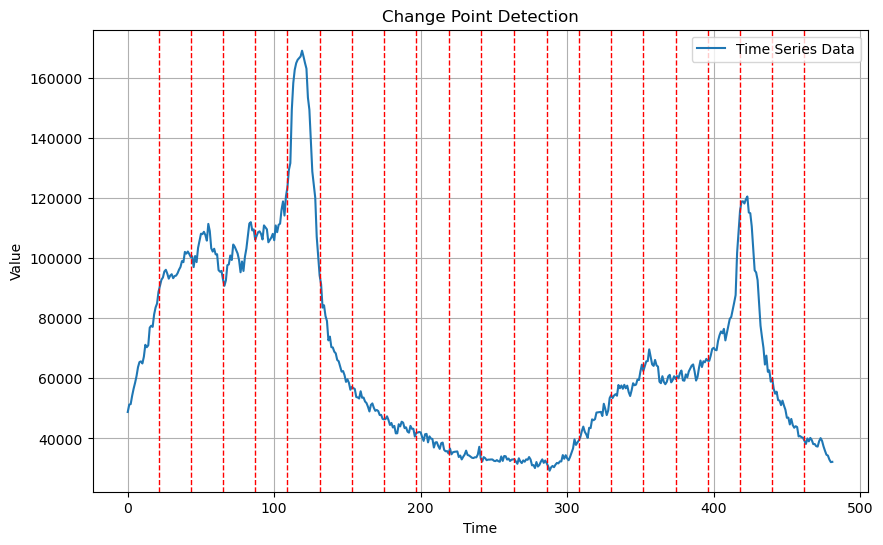

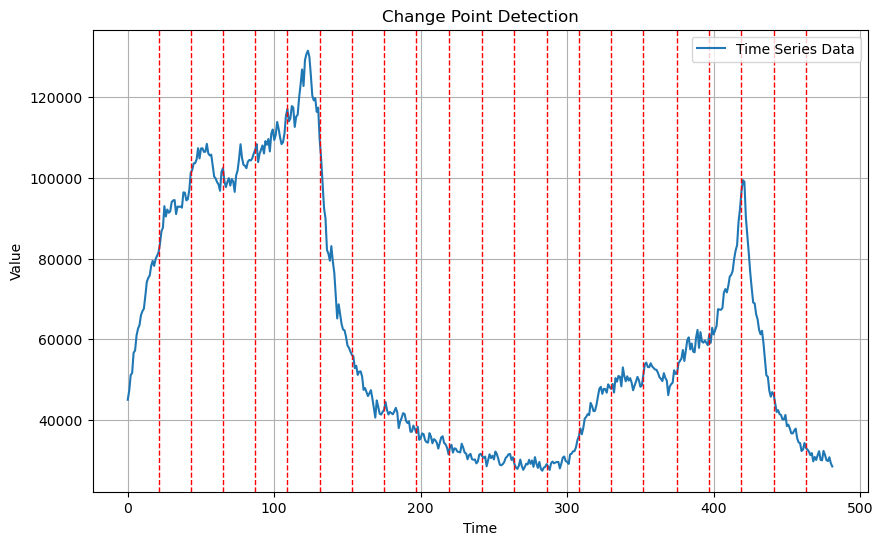

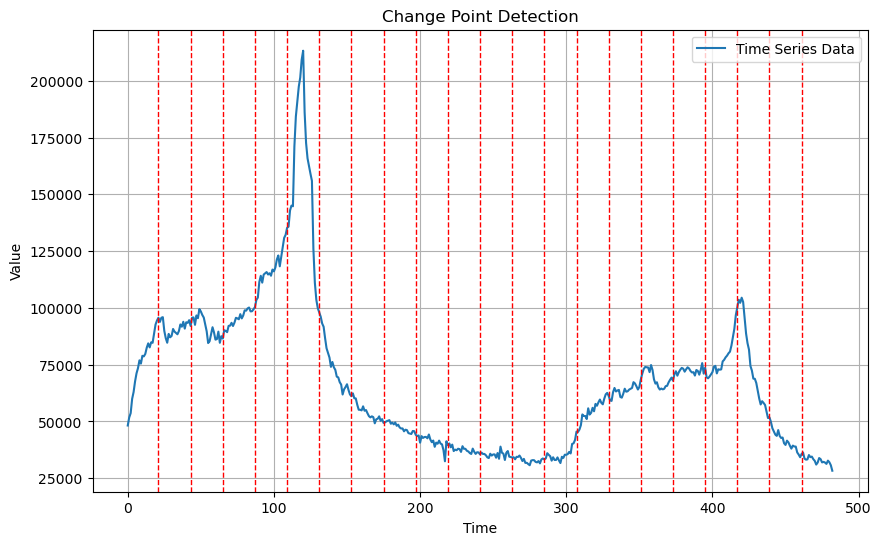

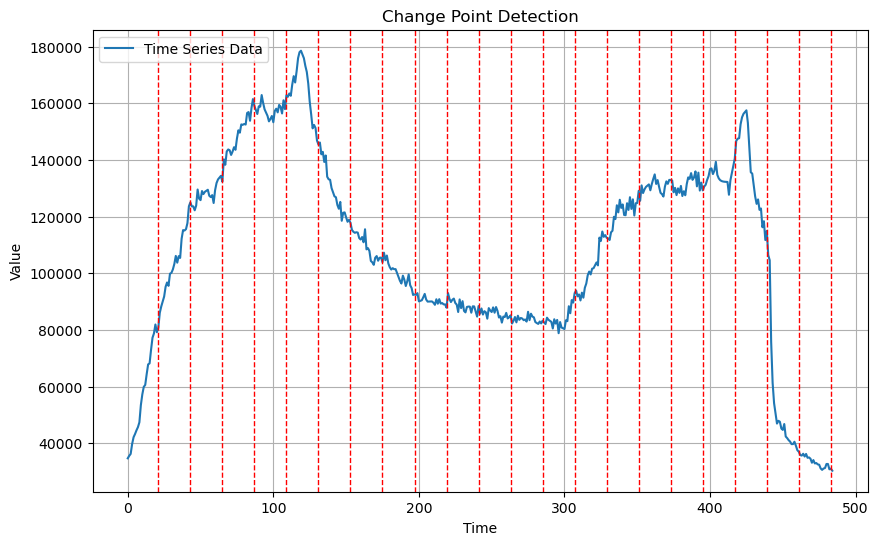

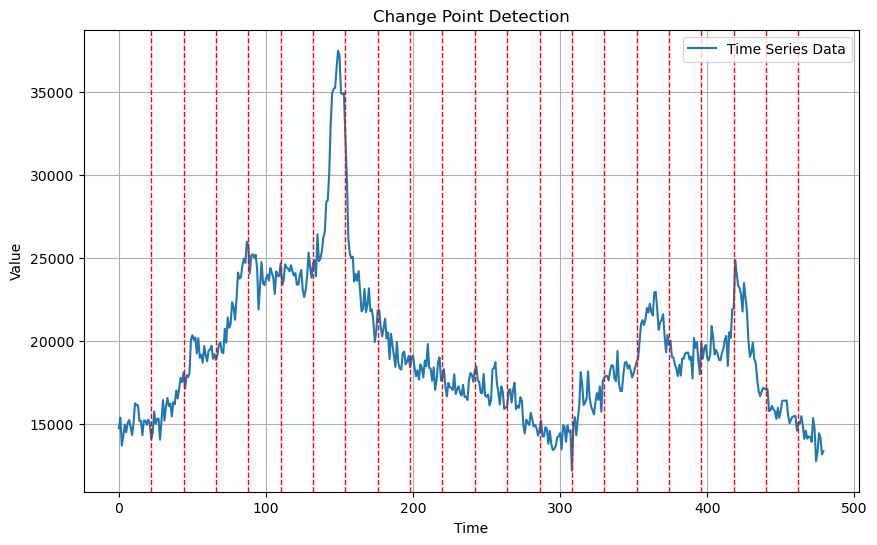

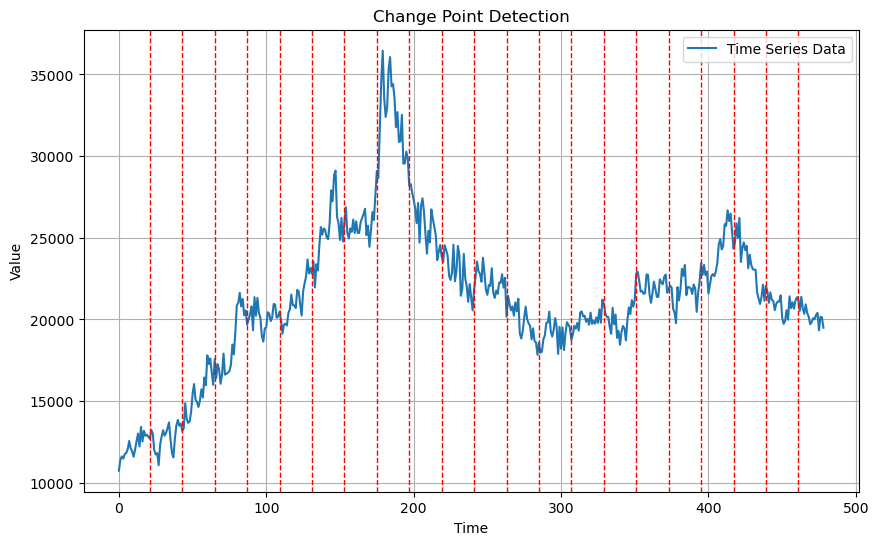

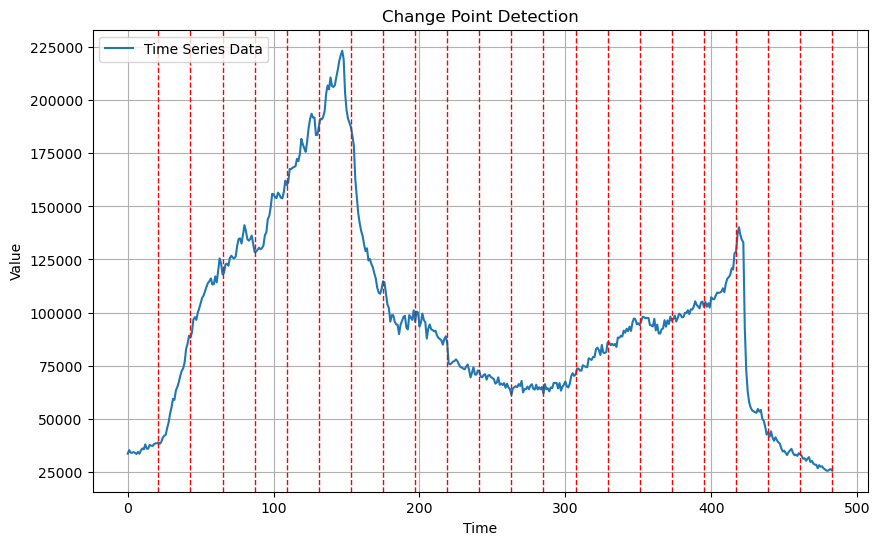

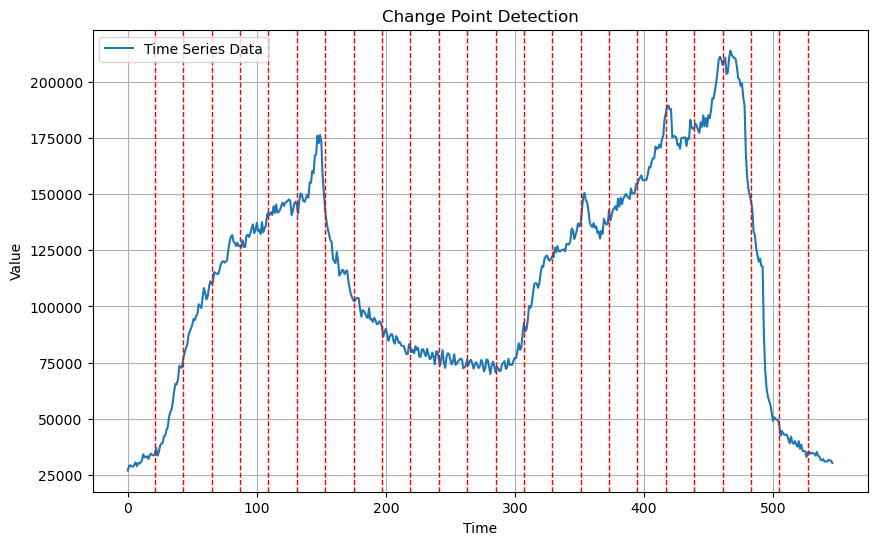

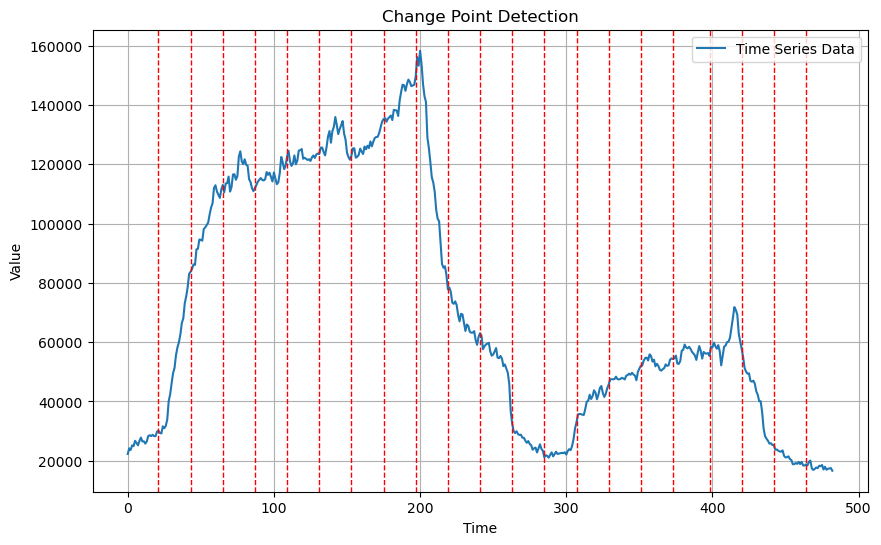

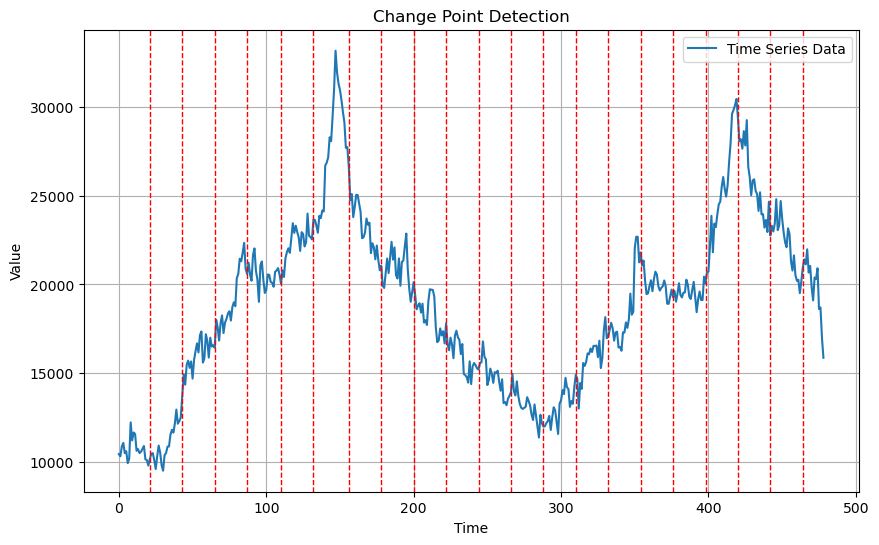

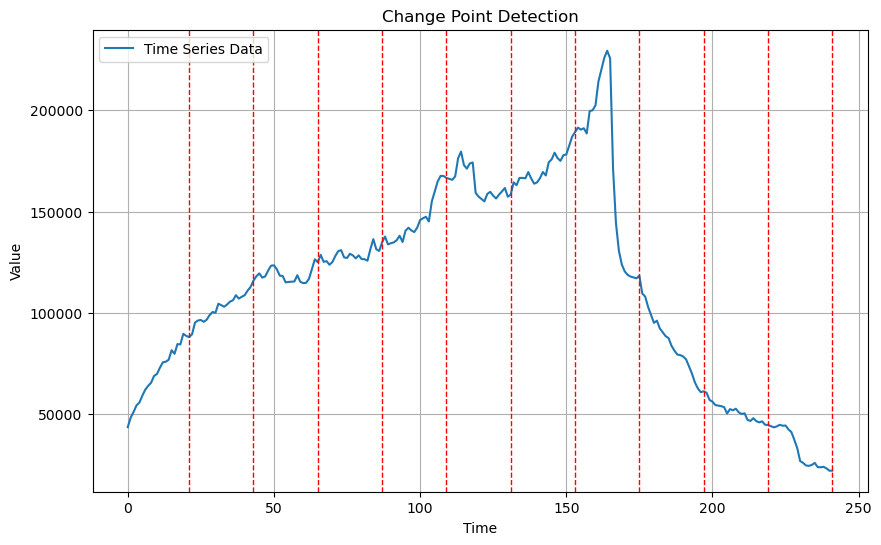

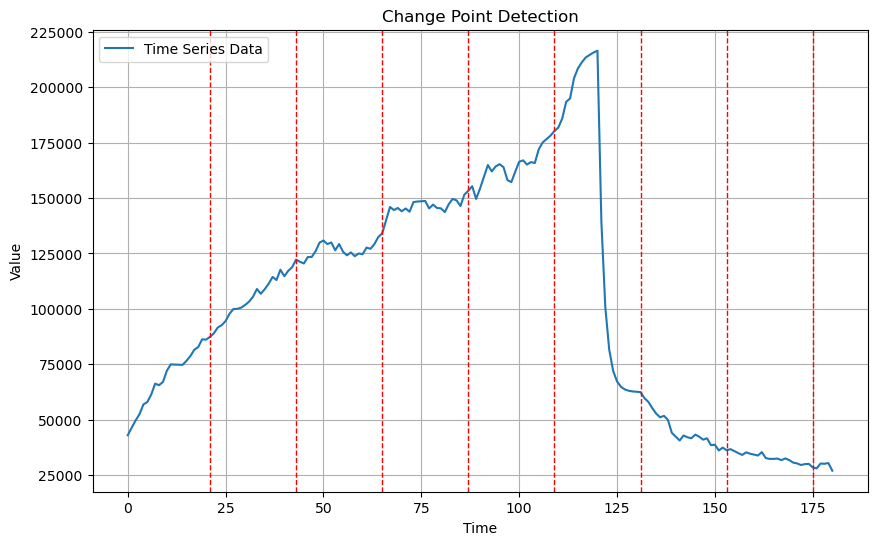

In [49]:
data_file_list = get_data_file_list(DATASET_PATH)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    gt, pd = get_gt_and_pd(workload_name, "test", is_scaled=False)
    gt = np.squeeze(gt)
    change_idx = clt_test(gt,20)
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(gt)), gt, label='Time Series Data')
    for cp in change_idx:
        plt.axvline(x=cp, color='red', linestyle='--', linewidth=1)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Change Point Detection')
    plt.legend()
    plt.grid(True)
    plt.show()